# Classificador de Formato de Placa (Antiga vs Mercosul)

Este notebook treina um classificador binário usando **MobileNetV2 com fine-tuning** para identificar se uma placa é do formato Antigo (`LLL-NNNN`) ou Mercosul (`LLLNLNN`).

A distinção visual principal é a **faixa azul no topo** das placas Mercosul. Com um modelo treinado, conseguimos detectar isso de forma muito mais robusta do que a análise manual de pixels.

## 1. Imports

In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(f'PyTorch: {torch.__version__}')
print(f'Device: {"GPU" if torch.cuda.is_available() else "CPU"}')

PyTorch: 2.11.0+cpu
Device: CPU


## 2. Preparação do Dataset

In [39]:
DATASET_PATH = './dataset/plates'

def normalizar(texto):
    return str(texto).upper().replace(' ', '').replace('-', '').strip()

def tipo_placa(texto):
    t = normalizar(texto)
    if len(t) == 7 and t[:3].isalpha() and t[3:].isdigit():
        return 'Antiga'
    elif len(t) == 7 and t[:3].isalpha() and t[3].isdigit() and t[4].isalpha() and t[5:].isdigit():
        return 'Mercosul'
    return 'Outro'

df = pd.read_csv(os.path.join(DATASET_PATH, 'plates.csv'))
df['tipo'] = df['plate'].apply(tipo_placa)
df['img_path'] = df['filename'].apply(lambda f: os.path.join(DATASET_PATH, str(f)))

# Remove as 3 placas 'Outro' — não servem para classificação binária
df = df[df['tipo'] != 'Outro'].reset_index(drop=True)
df['label'] = (df['tipo'] == 'Mercosul').astype(int)  # 0 = Antiga, 1 = Mercosul

print(df['tipo'].value_counts())
print(f'\nTotal: {len(df)} imagens')

tipo
Mercosul    137
Antiga       66
Name: count, dtype: int64

Total: 203 imagens


## 3. Divisão Treino / Validação

In [40]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],  # mantém proporção das classes
    random_state=42
)

print(f'Treino:    {len(train_df)} imagens ({train_df["tipo"].value_counts().to_dict()})')
print(f'Validação: {len(val_df)} imagens ({val_df["tipo"].value_counts().to_dict()})')

Treino:    162 imagens ({'Mercosul': 109, 'Antiga': 53})
Validação: 41 imagens ({'Mercosul': 28, 'Antiga': 13})


## 4. Dataset e DataLoaders

Aplicamos **data augmentation** no treino (flip, rotação, variação de brilho) para compensar o tamanho pequeno do dataset.

In [41]:
class PlacaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = int(row['label'])
        return img, label


# MobileNetV2 espera imagens 224x224 normalizadas com médias do ImageNet
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

transform_treino = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = PlacaDataset(train_df, transform=transform_treino)
val_dataset   = PlacaDataset(val_df,   transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)

print('DataLoaders prontos.')

DataLoaders prontos.


## 5. Modelo — MobileNetV2 com Fine-tuning

Carregamos o MobileNetV2 pré-treinado no ImageNet e substituímos apenas o classificador final por uma camada de 2 saídas (Antiga / Mercosul). O restante da rede permanece congelado — só a última camada aprende.

In [42]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.mobilenet_v2(weights='IMAGENET1K_V1')

# Congela todos os parâmetros
for param in model.parameters():
    param.requires_grad = False

# Descongela as últimas 3 camadas (features[-3:]) além do classificador
for param in model.features[-3:].parameters():
    param.requires_grad = True

# Substitui o classificador final
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, 2)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model.features[-3:].parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
])

print(f'Modelo carregado. Parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Modelo carregado. Parâmetros treináveis: 1,208,642


## 6. Treinamento

In [43]:
EPOCHS = 25

historico = {'train_loss': [], 'val_loss': [], 'val_acc': []}

melhor_acc = 0.0
melhor_estado = None

for epoch in range(1, EPOCHS + 1):
    # --- Treino ---
    model.train()
    train_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(imgs)
    train_loss /= len(train_dataset)

    # --- Validação ---
    model.eval()
    val_loss = 0.0
    corretos = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * len(imgs)
            preds = outputs.argmax(dim=1)
            corretos += (preds == labels).sum().item()
    val_loss /= len(val_dataset)
    val_acc = corretos / len(val_dataset)

    historico['train_loss'].append(train_loss)
    historico['val_loss'].append(val_loss)
    historico['val_acc'].append(val_acc)

    # Salva o melhor modelo
    if val_acc > melhor_acc:
        melhor_acc = val_acc
        melhor_estado = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d}/{EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.1%}')

print(f'\nMelhor acurácia de validação: {melhor_acc:.1%}')

Epoch  1/25 | train_loss: 0.5220 | val_loss: 0.3603 | val_acc: 85.4%
Epoch  5/25 | train_loss: 0.1040 | val_loss: 0.1440 | val_acc: 97.6%
Epoch 10/25 | train_loss: 0.0490 | val_loss: 0.0927 | val_acc: 97.6%
Epoch 15/25 | train_loss: 0.0977 | val_loss: 0.1050 | val_acc: 95.1%
Epoch 20/25 | train_loss: 0.0486 | val_loss: 0.0839 | val_acc: 97.6%
Epoch 25/25 | train_loss: 0.0638 | val_loss: 0.0774 | val_acc: 97.6%

Melhor acurácia de validação: 97.6%


## 7. Curvas de Aprendizado

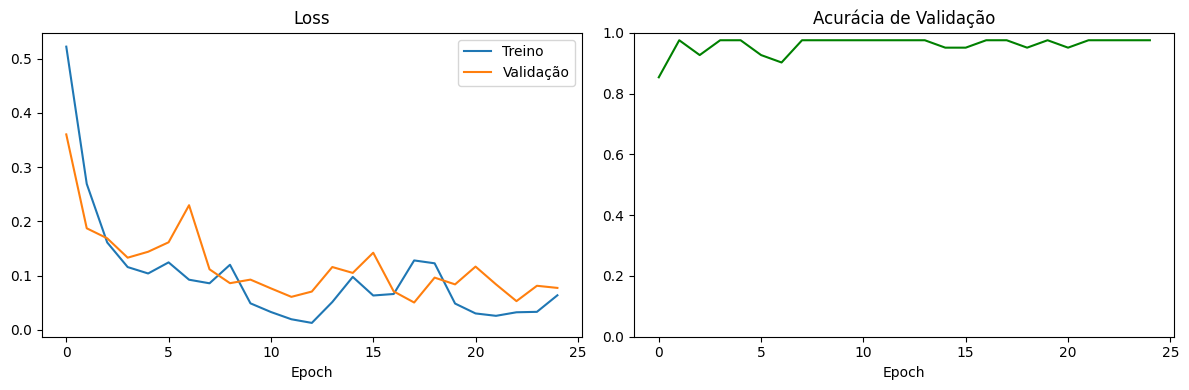

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historico['train_loss'], label='Treino')
ax1.plot(historico['val_loss'],   label='Validação')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(historico['val_acc'], color='green')
ax2.set_title('Acurácia de Validação')
ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 8. Avaliação Final

In [45]:
# Carrega o melhor estado salvo
model.load_state_dict(melhor_estado)
model.to(device)
model.eval()

todos_preds  = []
todos_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        todos_preds.extend(preds)
        todos_labels.extend(labels.numpy())

print(classification_report(todos_labels, todos_preds, target_names=['Antiga', 'Mercosul']))

cm = confusion_matrix(todos_labels, todos_preds)
print('Matriz de confusão:')
print(f'            Pred Antiga  Pred Mercosul')
print(f'Real Antiga      {cm[0,0]:4d}          {cm[0,1]:4d}')
print(f'Real Mercosul    {cm[1,0]:4d}          {cm[1,1]:4d}')

              precision    recall  f1-score   support

      Antiga       1.00      0.92      0.96        13
    Mercosul       0.97      1.00      0.98        28

    accuracy                           0.98        41
   macro avg       0.98      0.96      0.97        41
weighted avg       0.98      0.98      0.98        41

Matriz de confusão:
            Pred Antiga  Pred Mercosul
Real Antiga        12             1
Real Mercosul       0            28


## 9. Salvar o Modelo

In [46]:
MODEL_PATH = './modelo_formato_placa.pth'
torch.save(melhor_estado, MODEL_PATH)
print(f'Modelo salvo em: {MODEL_PATH}')

Modelo salvo em: ./modelo_formato_placa.pth


## 10. Integração com o Pós-Processamento

Função `detectar_formato_nn()` substitui a detecção por pixels do notebook anterior.

In [47]:
def carregar_modelo_formato(model_path: str):
    """Carrega o classificador treinado."""
    m = models.mobilenet_v2(weights=None)
    m.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(m.last_channel, 2)
    )
    m.load_state_dict(torch.load(model_path, map_location='cpu'))
    m.eval()
    return m


_transform_infer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def detectar_formato_nn(img_path: str, modelo) -> str:
    """
    Detecta o formato da placa usando o classificador treinado.
    Retorna 'mercosul' ou 'antiga'.
    """
    img = Image.open(img_path).convert('RGB')
    tensor = _transform_infer(img).unsqueeze(0)  # adiciona dimensão de batch
    with torch.no_grad():
        output = modelo(tensor)
        pred = output.argmax(dim=1).item()
    return 'mercosul' if pred == 1 else 'antiga'


# Teste rápido com as primeiras 5 imagens do val
modelo_carregado = carregar_modelo_formato(MODEL_PATH)

print(f'{"Arquivo":<30} {"Real":>10} {"Predito":>10} {"✓"}')
print('-' * 55)
for _, row in val_df.head(5).iterrows():
    predito = detectar_formato_nn(row['img_path'], modelo_carregado)
    real    = row['tipo'].lower()
    ok = '✓' if predito == real else '✗'
    print(f"{row['filename']:<30} {real:>10} {predito:>10} {ok}")

Arquivo                              Real    Predito ✓
-------------------------------------------------------
plate_imgs/plate_16.jpg            antiga     antiga ✓
plate_imgs/plate_143.jpg         mercosul   mercosul ✓
plate_imgs/plate_27.jpg          mercosul   mercosul ✓
plate_imgs/plate_12.jpg          mercosul   mercosul ✓
plate_imgs/plate_180.jpg           antiga   mercosul ✗
